# 7. Monte Carlo savings projections

**Question:** what range of outcomes can a savings plan expect, and how much can a retiree
withdraw?

The example plan saves €500 a month for 30 years, then withdraws 4% of the starting wealth a year
for another 30 years. Both amounts rise with inflation. Fund costs are 0.2% a year, and all
results are in today's money.

Three return models are compared:

* **GBM:** independent lognormal monthly returns, calibrated to history.
* **Student-t:** the same mean and variance of log returns as GBM, with fat-tailed shocks.
* **Block bootstrap:** real months resampled in blocks (12 months on average), together with that
  month's inflation. This keeps runs of good and bad months, volatility clusters and the link
  between returns and inflation.

Taxes follow the German rules for accumulating funds in a taxable account (`investor_toolkit.tax`).
Each allocation is held as separate equity and bond ETFs, so its partial exemption is 30% times
the equity share: 7.5% for 25/75, 18% for 60/40 and 30% for 100% equity.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import montecarlo as mc
from investor_toolkit import proxies
from investor_toolkit.plotting import plot_fan, plot_lines
from investor_toolkit.tax import GermanTax, blended_partial_exemption

In [2]:
long = proxies.long_history()
allocations = {
    "defensive (25/75)": (0.25 * long["world_equity"] + 0.75 * long["bund_10y"], 0.25),
    "balanced (60/40)": (0.60 * long["world_equity"] + 0.40 * long["bund_10y"], 0.60),
    "growth (100/0)": (long["world_equity"], 1.00),
}


def taxes_for(equity_share):
    return GermanTax(partial_exemption=blended_partial_exemption(equity_share))


history, equity_share = allocations["balanced (60/40)"]
plan = mc.SavingsPlan(
    monthly_contribution=500,
    accumulation_years=30,
    withdrawal_years=30,
    withdrawal_rate=0.04,
    annual_fee=0.002,
    tax=taxes_for(equity_share),
)
gbm = mc.GBM.from_returns(history, inflation=long["inflation"].mean() * 12)
models = {
    "GBM": gbm,
    "Student-t (df 5)": mc.StudentT(gbm.expected_return, gbm.volatility, gbm.inflation, df=5.0),
    "Block bootstrap": mc.Bootstrap(history, long["inflation"], mean_block=12),
}
print(
    f"Calibration: expected return {gbm.expected_return:.2%}, volatility {gbm.volatility:.2%}, "
    f"inflation {gbm.inflation:.2%}"
)
results = {name: mc.simulate(model, plan, n_paths=10_000, seed=1) for name, model in models.items()}
pd.DataFrame({name: r.summary() for name, r in results.items()})

Calibration: expected return 6.48%, volatility 8.69%, inflation 2.18%


,GBM,Student-t (df 5),Block bootstrap
invested_real,180000.000,180000.000,180000.000
retirement_median,319760.493,318098.476,321688.134
retirement_p5,196228.748,195774.232,178919.548
retirement_p95,538982.833,536407.289,573166.348
terminal_median,90212.489,92155.741,95781.311
terminal_after_tax_median,77027.576,78764.435,81968.256
taxes_paid_real_mean,91273.087,91437.013,93350.078
success_rate,0.707,0.716,0.686


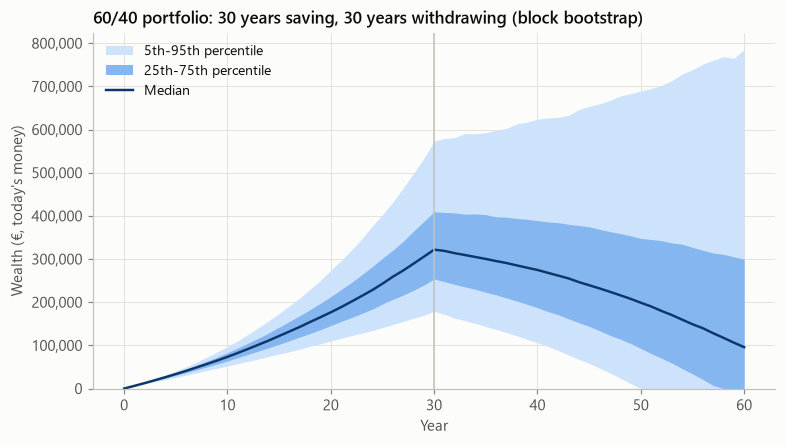

In [3]:
boot = results["Block bootstrap"]
ax = plot_fan(
    boot.percentiles(),
    title="60/40 portfolio: 30 years saving, 30 years withdrawing (block bootstrap)",
    ylabel="Wealth (€, today's money)",
)
ax.axvline(30, color="#c3c2b7", linewidth=1.0)
ax.figure.savefig(f"{FIGURES}/savings_fan.png")

GBM and Student-t agree closely: over decades, fat tails in single months average out. The
bootstrap gives a wider range and a lower success rate because it keeps what the other two
discard: runs of bad months, and periods when high inflation meets weak returns. Such runs early
in retirement are what make withdrawal plans fail.

## What taxes cost

In [4]:
rows = {}
for name, (series, share) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    for label, tax in [("tax-free", None), ("taxable", taxes_for(share))]:
        p = mc.SavingsPlan(
            monthly_contribution=500, accumulation_years=30, annual_fee=0.002, tax=tax
        )
        s = mc.simulate(model, p, n_paths=10_000, seed=1).summary()
        rows[(name, label)] = {
            "paid in": s["invested_real"],
            "median before selling": s["retirement_median"],
            "median after tax on the sale": s["terminal_after_tax_median"],
            "5th percentile before selling": s["retirement_p5"],
            "advance tax paid while saving (mean)": s["taxes_paid_real_mean"],
        }
pd.DataFrame(rows).T.round(0)

paid in  median before selling  median after tax on the sale  \
defensive (25/75) tax-free  180000.0               240215.0                      240215.0   
                  taxable   180000.0               233603.0                      216018.0   
balanced (60/40)  tax-free  180000.0               330065.0                      330065.0   
                  taxable   180000.0               321308.0                      288535.0   
growth (100/0)    tax-free  180000.0               467963.0                      467963.0   
                  taxable   180000.0               457727.0                      405664.0   

                            5th percentile before selling  advance tax paid while saving (mean)  
defensive (25/75) tax-free                       157457.0                                   0.0  
                  taxable                        154253.0                                6117.0  
balanced (60/40)  tax-free                       179199.0                                   0.0  
                  taxable                        176199.0                                7521.0  
growth (100/0)    tax-free                       165148.0                                   0.0  
                  taxable                        163243.0                                9180.0

While saving, the yearly advance tax (Vorabpauschale) adds up to little; most of the tax falls
due when the fund is sold. Equity ETFs are 30% exempt and bond ETFs not at all, so the tax takes
a larger share of the gain in bond-heavy portfolios.

## How much can be withdrawn safely?

The safe withdrawal rate is the highest first-year withdrawal, as a share of the starting wealth
and then raised with inflation, that lasts the full period in at least 95% of the histories.
Shown for a tax-free account with 0.2% fund costs.

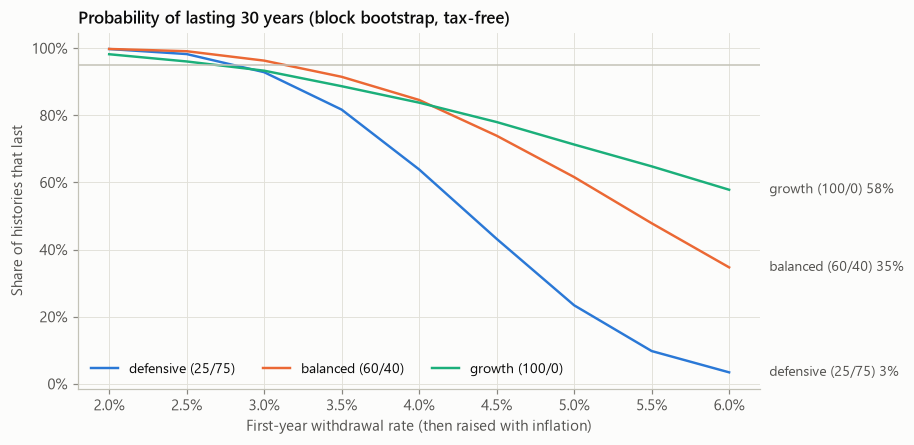

In [5]:
rates = np.round(np.arange(0.02, 0.061, 0.005), 3)
curves = {}
for name, (series, _) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    curves[name] = [
        mc.simulate(
            model,
            mc.SavingsPlan(
                initial=100_000,
                monthly_contribution=0,
                accumulation_years=0,
                withdrawal_years=30,
                withdrawal_rate=rate,
                annual_fee=0.002,
            ),
            n_paths=4000,
            seed=2,
        ).success_rate()
        for rate in rates
    ]
success = pd.DataFrame(curves, index=rates)
ax = plot_lines(
    success,
    title="Probability of lasting 30 years (block bootstrap, tax-free)",
    percent=True,
    label_fmt=lambda v: f"{v:.0%}",
    legend_loc="lower left",
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.set_xlabel("First-year withdrawal rate (then raised with inflation)")
ax.set_ylabel("Share of histories that last")
ax.axhline(0.95, color="#c3c2b7", linewidth=1.0)
ax.figure.savefig(f"{FIGURES}/withdrawal_success.png")

In [6]:
swr = {}
for name, (series, _) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    for years in (20, 30, 40):
        p = mc.SavingsPlan(
            initial=100_000,
            monthly_contribution=0,
            accumulation_years=0,
            withdrawal_years=years,
            annual_fee=0.002,
        )
        swr[(name, years)] = mc.safe_withdrawal_rate(model, p, target_success=0.95, n_paths=2000)
(pd.Series(swr).unstack() * 100).round(2).rename_axis(
    index="safe withdrawal rate (%)", columns="years"
)

years,20,30,40
safe withdrawal rate (%),,,
balanced (60/40),4.47,3.15,2.57
defensive (25/75),4.24,2.83,2.20
growth (100/0),3.85,2.72,2.18


Over 30 years, the rate that lasted in 95% of the histories was below 4% for every allocation.
Longer retirements require lower rates.

## How much do these results depend on the past?

Every result above resamples one 27-year history, in which the 60/40 portfolio earned about 6% a
year. A history that is two or three decades long contains only a few independent bear markets,
so the future could easily be less generous. The same simulations with 1 and 2 percentage points
less return per year:

In [7]:
saver = mc.SavingsPlan(
    monthly_contribution=500, accumulation_years=30, annual_fee=0.002, tax=taxes_for(0.6)
)
rows = {}
for cut in (0.0, 0.01, 0.02):
    model = mc.Bootstrap(history, long["inflation"], mean_block=12, return_adjustment=-cut / 12)
    outcome = mc.simulate(model, saver, n_paths=10_000, seed=1).terminal(after_tax=True)
    lasts = {}
    for rate in (0.04, 0.03):
        p = mc.SavingsPlan(
            initial=100_000,
            monthly_contribution=0,
            accumulation_years=0,
            withdrawal_years=30,
            withdrawal_rate=rate,
            annual_fee=0.002,
        )
        lasts[rate] = mc.simulate(model, p, n_paths=10_000, seed=2).success_rate()
    rows["as in history" if cut == 0 else f"{cut:.0%} less a year"] = {
        "savings: median after tax": np.median(outcome),
        "savings: 5th percentile after tax": np.percentile(outcome, 5),
        "4% withdrawals last 30 years": lasts[0.04],
        "3% withdrawals last 30 years": lasts[0.03],
    }
pd.DataFrame(rows).T.rename_axis("return vs history").round(3)

,savings: median after tax,savings: 5th percentile after tax,4% withdrawals last 30 years,3% withdrawals last 30 years
return vs history,,,,
as in history,288535.217,170121.169,0.838,0.967
1% less a year,248132.700,150240.737,0.714,0.922
2% less a year,215122.057,131570.048,0.550,0.841


One percentage point less return a year lowers the median savings result by about 14% and the
4% rule's success from about 84% to 71%. The 3% rule degrades much more slowly. Treat the
headline numbers as one plausible scenario, not a forecast.

**Takeaways**

* After 30 years of saving, the 95th percentile is about three times the 5th: plan for a range,
  not a number.
* Over long horizons, fat tails in single months matter less than sequences of returns and
  inflation.
* Most of the tax is due on the final sale; partial exemptions favour equity ETFs.
* A first-year withdrawal of about 3% was robust in this history; 4% was not, and both depend on
  future returns resembling the past.